# Average run length simulation

Null run-length distribution of `GridDetector` with `MeanCUSUM` for several
target average run lengths ($\mathrm{ARL}_0 = 10, 100, 1000$). For each
target the threshold is calibrated with `calibrate_threshold_arl`, null
streams are simulated with the calibrated detector, and the distribution of
individual run lengths is compared against the theoretical $\mathrm{Exp}$
approximation (mean equal to the target $\mathrm{ARL}_0$).

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold_arl,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUM

## Simulation parameters

In [2]:
TARGET_ARLS = [10, 100, 1000]  # target ARL_0 values to simulate
K_CAL = 1_000_000   # streams used to calibrate each threshold
N_SIM = 1_000_000   # streams whose run lengths form the plotted distribution
L_MAX_FACTOR = 10   # horizon = L_MAX_FACTOR * target ARL
RNG_CAL, RNG_TEST = 0, 1


def sampler(rng):
    """Draw one standard normal observation (null distribution)."""
    return rng.standard_normal()

## Calibrate and simulate for each target ARL

In [3]:
def run_arl_simulation(target_arl):
    """Calibrate, simulate null streams, and save run lengths for one target ARL."""
    score = MeanCUSUM(enable_penalty=False)
    detector = GridDetector(score=score)

    t0 = time.perf_counter()
    threshold = calibrate_threshold_arl(
        score,
        target_arl=target_arl,
        n_paths=K_CAL,
        pre_sampler=sampler,
        rng=RNG_CAL,
    )
    print(
        f"Calibrated threshold for target ARL {target_arl}: {threshold}"
        f"  ({time.perf_counter() - t0:.1f}s)"
    )

    detector_cal = with_calibrated_threshold(detector, threshold)
    stream_len = L_MAX_FACTOR * target_arl
    t0 = time.perf_counter()
    alarm_times = mc_alarm_times(
        detector_cal,
        N_SIM,
        stream_len,
        pre_sampler=sampler,
        rng=RNG_TEST,
    )
    print(
        f"Simulated {N_SIM} streams (horizon {stream_len})"
        f"  ({time.perf_counter() - t0:.1f}s)"
    )

    # Censored streams (no alarm by the horizon) have alarm_times == stream_len.
    n_censored = int(np.sum(alarm_times == stream_len))
    run_lengths = alarm_times + 1
    empirical_arl = float(np.mean(run_lengths))
    arl_se = float(np.std(run_lengths)) / np.sqrt(N_SIM)
    print(f"Censored streams: {n_censored} of {N_SIM}")
    print(f"Empirical ARL (mean run length): {empirical_arl:.1f} ± {arl_se:.1f} (SE)")

    results_path = f"simulation_results/arl_dist_sim_results_arl{target_arl}.npz"
    np.savez(
        results_path,
        target_arl=target_arl,
        threshold=threshold,
        stream_len=stream_len,
        alarm_times=alarm_times,
    )
    print(f"Saved results to {results_path}")

# WARNING: Takes a long time with 1 million simulations per ARL. Adjust K_CAL and N_SIM for quicker runs.
#start_time = time.perf_counter()
#for target_arl in TARGET_ARLS:
#    run_arl_simulation(target_arl)
#print(f"Total simulation time: {time.perf_counter() - start_time:.1f}s")

## Run-length distributions

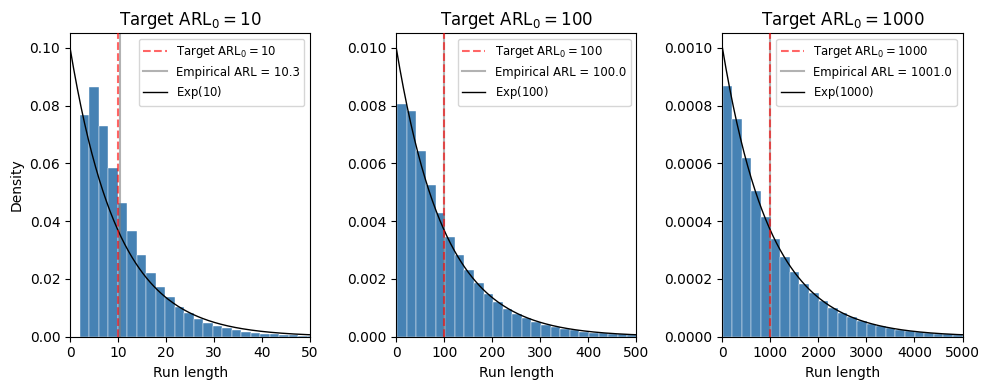

In [ ]:
def draw_run_length_panel(ax, results_path, n_bins=50):
    """Draw the null run-length histogram and Exp(target ARL) overlay on ``ax``.

    Loads ``results_path`` (one run length per simulated stream), plots the
    histogram with vertical lines at the target and empirical ARL, and overlays
    the exponential pdf with mean equal to the target ARL.
    """
    panel_data = np.load(results_path)
    target = int(panel_data["target_arl"])
    panel_run_lengths = panel_data["alarm_times"] + 1
    panel_arl = float(np.mean(panel_run_lengths))

    _, panel_edges, _ = ax.hist(
        panel_run_lengths,
        bins=n_bins,
        density=True,
        color="steelblue",
        edgecolor="white",
        linewidth=0.3,
    )
    ax.axvline(
        target,
        color="r",
        linestyle="--",
        linewidth=1.5,
        alpha=0.6,
        zorder=3,
        label=rf"Target $\mathrm{{ARL}}_0 = {target}$",
    )
    ax.axvline(
        panel_arl,
        color="gray",
        linestyle="-",
        linewidth=1.5,
        alpha=0.6,
        zorder=2,
        label=f"Empirical ARL = {panel_arl:.1f}",
    )

    x = np.linspace(0.0, panel_edges[-1], 400)
    exp_pdf = np.exp(-x / target) / target
    ax.plot(x, exp_pdf, color="black", linewidth=1, label=rf"Exp(${target}$)")

    ax.set_xlabel("Run length")
    ax.set_title(rf"Target $\mathrm{{ARL}}_0 = {target}$")
    ax.set_xlim(0, 5 * target)  # zoom in on the main mass of the distribution
    ax.legend(fontsize="small")


fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for panel_ax, panel_target in zip(axes, TARGET_ARLS):
    draw_run_length_panel(panel_ax, f"simulation_results/arl_dist_sim_results_arl{panel_target}.npz")
axes[0].set_ylabel("Density")

plt.tight_layout()
#plt.savefig("arl_dist_sim_grid.pdf", bbox_inches="tight")
plt.show()